# Work with images

- Data set: https://www.repository.cam.ac.uk/items/b6a97f0c-3b9b-40ad-8f18-3d121eef1459
- Data set location: ./MIASDBv1.21
- Author: Jared Ramirez Escalante

This work will be organize in the next sections

- **Environment setup**
- **Data preparation**
- **Data augmentation**
- **Transfer learning**
- **Iteration**

First we would explore the final data pipeline, but in iterations we will see the different changes this pipeline had.

# Environment Setup

Besides the model result which will be discuss later, this was the most difficult part of the work, given the computational limitations for what was done, there where two machines use, which led me to the use of many different optimizations of the setup and also the use of the different machines that will be presented below

### Collab Machine

### Local Machine

As seen the second machine is faster than the first machine, but lacking vram which would be a constant problem thought the work, for that reason thw notebook was made in a way in which it could be easily run on Collab or in the local machine, depending on the necessities.

In local conda was use, in a kernel made with the next specifications

Here we define a variable useful depending if run local or cloud.

In [13]:
local = True
if local:
    !uv pip install numpy matplotlib opencv-python pandas albumentations scikit-learn seaborn
else:
    !pip install pypnm torch numpy matplotlib opencv-python pandas 

/usr/bin/zsh: /home/turing/miniconda3/envs/ia_env/lib/libncursesw.so.6: no version information available (required by /usr/bin/zsh)
Using Python 3.10.20 environment at: /home/turing/miniconda3/envs/ia_env
Checked 7 packages in 3ms


Here are some necessities for the local use, given that i couldn't uses the Cuda device, because a file could be found, thus it copies it to a directory it can be found.

In [14]:
if local:
    import os
    import shutil

    conda_prefix = os.environ.get("CONDA_PREFIX", "/home/turing/miniconda3/envs/ia_env")
    posibles_origenes = [
        os.path.join(conda_prefix, "lib/nvvm/libdevice/libdevice.10.bc"),
        "/usr/local/cuda/nvvm/libdevice/libdevice.10.bc",
        "/opt/cuda/nvvm/libdevice/libdevice.10.bc" 
    ]

    destino_dir = os.path.join(os.getcwd(), "nvvm", "libdevice")
    os.makedirs(destino_dir, exist_ok=True)
    destino_archivo = os.path.join(destino_dir, "libdevice.10.bc")

    copiado_con_exito = False
    for ruta in posibles_origenes:
        if os.path.exists(ruta):
            shutil.copy(ruta, destino_archivo)
            shutil.copy(ruta, os.path.join(os.getcwd(), "libdevice.10.bc"))
            copiado_con_exito = True
            break

    if not copiado_con_exito:
        print("Error")

os.environ["XLA_FLAGS"] = f"--xla_gpu_cuda_data_dir={os.getcwd()}"

Here some memory optimization were made, given that it was the mayor obstacle

- Asynchronous Memory Allocation: Reduces overhead by creating an asynchronous memory pool instead of triggering heavy, blocking system calls
- Dynamic VRAM Allocation: Prevents TF allocating 100% of vram, avoiding system freezing
- Mixed Precision Training: Switches the global computation policy to 16-bit floating-point math (float16) while maintaining 32-bit stability where needed. This really reduced vram usage and accelerated training, without noticeable reduction in model performance. 

In [15]:

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
import shutil
import cv2
import pandas as pd
import albumentations as A
import tensorflow as tf
from tensorflow.keras import mixed_precision



gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Data Preparation

First we load the images, if local we use acces the directory where there are, if cloud, we access a drive, and we copy its content to the Collab VM. After that we shuffle the images and separate theme in train, validation and test. 

In [16]:
if local:
    ruta_carpeta = "./MIASDBv1.21"
else: 
    from google.colab import drive
    drive.mount('/content/drive')
    ruta_zip_drive = "/content/drive/MyDrive/6 semestre/IA/miasdbv1.21.zip"
    ruta_local_mv = "/content/mias_local"
    ruta_carpeta = os.path.join(ruta_local_mv, "MIASDBv1.21")
    
    if not os.path.exists(ruta_local_mv) or not os.listdir(ruta_local_mv):
        print("Copiando y descomprimiendo dataset...")
        os.makedirs(ruta_local_mv, exist_ok=True)
        os.system(f'cp "{ruta_zip_drive}" /content/temp.zip')
        os.system(f'unzip -q /content/temp.zip -d "{ruta_local_mv}"')
        os.system('rm /content/temp.zip')
        
    if not os.path.exists(ruta_carpeta):
        ruta_carpeta = ruta_local_mv


imagenes = [f for f in os.listdir(ruta_carpeta) if f.endswith('.pgm')]
random.seed(42)
random.shuffle(imagenes)


len_imagenes = len(imagenes)
limite_train = int(len_imagenes * 0.70)
limite_val = int(len_imagenes * 0.85)
files_train = imagenes[:limite_train]
files_val = imagenes[limite_train:limite_val]
files_test = imagenes[limite_val:]
print(f"Imágenes encontradas en Train: {len(files_train)}")

Imágenes encontradas en Train: 225


In [17]:
tamaños_detectados = {}

for archivo in imagenes:
    ruta_completa = os.path.join(ruta_carpeta, archivo)
    img = cv2.imread(ruta_completa, cv2.IMREAD_UNCHANGED)
    if img is not None:
        dimensiones = img.shape
        if dimensiones in tamaños_detectados:
            tamaños_detectados[dimensiones] += 1
        else:
            tamaños_detectados[dimensiones] = 1

for dim, conteo in tamaños_detectados.items():
    print(f"Dimensiones {dim}: {conteo} imágenes")

Dimensiones (2600, 4320): 149 imágenes
Dimensiones (2048, 4320): 101 imágenes
Dimensiones (4000, 5200): 24 imágenes
Dimensiones (1600, 4320): 48 imágenes


We still are missing the data that is not in the images so we extracted the text, and with that we get the labels for the images. After that this are the steps of the data pipeline. 

* **Vertical Cropping (Aspect Ratio Guard):** Checks if the raw image is extremely tall (over 4500px) and crops out the useless black margins at the top and bottom (`400:4800`) to focus on the actual medical region of interest.
* **Contrast Enhancement (CLAHE):** Automatically applies Contrast Limited Adaptive Histogram Equalization to normalise and boost local image contrast, making subtle patterns far easier for the model to detect.
* **Aspect-Ratio Preserved Resizing:** Scales the images down using area interpolation (`INTER_AREA`, which prevents aliasing in downsampling) while strictly maintaining their original aspect ratio.
* **Centered Square Padding:** Pads the resized image onto a standardized 224x224 canvas using centered black bars, followed by float32 division `/ 255.0` to quickly normalize pixel values for neural networks.
* **Metadata Alignment:** Maps custom codes from medical filenames against the ground truth table to group images into three categorical targets: Normal (0), Benign (1), or Malignant (2).

In [18]:
mias_truth_data = """
mdb001lm G CIRC B 1815 1116 790
mdb002rl G CIRC B 3091 1262 277
mdb00311 D NORM
mdb004rl D NORM
mdb005ll F CIRC B 647 1163 122
mdb006rl F NORM
mdb00711 G NORM
mdb008rl G NORM
mdb009ll F NORM
mdb010rm F CIRC B 2509 975 135
mdb011ll F NORM
mdb012rl F CIRC B 2378 1467 162
mdb013ll G MISC B 1574 1923 127
mdb014rl G NORM
mdb015lm G CIRC B 3571 1359 275
mdb016rm G NORM
mdb017ls G CIRC B 2407 943 192
mdb018rs G NORM
mdb019ll G CIRC B 2021 1864 197
mdb020rl G NORM
mdb021ll G CIRC B 612 1224 197
mdb022rm G NORM
mdb023ll G CIRC M 2837 1405 117
mdb024rl G NORM
mdb025ll F CIRC B 1886 1948 318
mdb026rl F NORM
mdb027ll F NORM
mdb028rl F CIRC M 2953 1999 224
mdb029ll G NORM
mdb030rm G MISC B 1505 1785 174
mdb031ll G NORM
mdb032rl G MISC B 1243 1798 267
mdb033ls D NORM
mdb034rs D NORM
mdb035ls D NORM
mdb036rs D NORM
mdb037ls D NORM
mdb038rs D NORM
mdb039ls D NORM
mdb040rs D NORM
mdb041ll G NORM
mdb042rl G NORM
mdb043ls G NORM
mdb044rs G NORM
mdb045lm G NORM
mdb046rm G NORM
mdb047lm G NORM
mdb048rm G NORM
mdb049ll G NORM
mdb050rl G NORM
mdb051ll G NORM
mdb052rm G NORM
mdb053ls D NORM
mdb054rs D NORM
mdb055lm G NORM
mdb056rm G NORM
mdb057ll D NORM
mdb058rl D MISC M 2774 2079 110
mdb059ls F CIRC B
mdb060rs F NORM
mdb061ls D NORM
mdb062rs D NORM
mdb063lm D MISC B 1967 133 1163
mdb064rm D NORM
mdb065lm D NORM
mdb066rm D NORM
mdb067ll D NORM
mdb068rl D NORM
mdb069ll F CIRC B 1739 177 1101
mdb070rl F NORM
mdb071lm G NORM
mdb072rm G ASYM M 2140 115  2011
mdb073ls G NORM
mdb074rs G NORM
mdb075lm F ASYM M 2982 92 850
mdb076rm F NORM
mdb077ll F NORM
mdb078rl F NORM
mdb079lm F NORM
mdb080rm F CIRC B 3615 1344 81
mdb081ll G ASYM B 2007 1220 525
mdb082rl G NORM
mdb08311 G ASYM B 891 1428 152
mdb084rl G NORM
mdb085lm G NORM
mdb086rm G NORM
mdb087lm F NORM
mdb088rm F NORM
mdb089lm G NORM
mdb090rm G ASYM M 2021 1035 198
mdb091lm F CIRC B 2090 1696 82
mdb092rm F ASYM M 1562 1382 175
mdb093lm G NORM
mdb094rm G NORM
mdb095ll F ASYM M 2181 1118 116
mdb096rl F NORM
mdb09711 F ASYM B 1302 1702 137
mdb098rl F NORM
mdb099lm D ASYM B 1473 1834 93
mdb100rm D NORM
mdb101lm D NORM
mdb102rm D ASYM M 2369 1412 152
mdb103lm D NORM
mdb104rm D ASYM B 2751 1645 203
mdb105ll D ASYM M 1229 1318 392
mdb106rl D NORM
mdb107ll D ASYM B 2597 1653 446
mdb108rl D NORM
mdb109ll D NORM
mdb110rl D ASYM M 2502 2590 205
mdb111ll D ASYM M 2414 1275 428
mdb112rl D NORM
mdb113ls G NORM
mdb114rs G NORM
mdb115ll G ARCH M 2240 1096 468
mdb116rl G NORM
mdb117ll G ARCH M 2417 1175 337
mdb118rl G NORM
mdb119ll G NORM
mdb120rl G ARCH M 3162 1659 319
mdb121ll G ARCH B 1849 1221 348
mdb122rl G NORM
mdb123lm G NORM
mdb124rm G ARCH M 1729 1609 135
mdb125ll D ARCH M 2322 2054 242
mdb126rl D ARCH B 2015 2585 93
mdb127lm G ARCH B 2317 1069 194
mdb128rm G NORM
mdb129ll D NORM
mdb130rl D ARCH M 2002 2469 112
mdb131lx F NORM
mdb132rx F CIRC B 1499 3043 211
mdb133lx F NORM
mdb134rx F MISC M 1736 2173 199
mdb135lx F NORM
mdb136rx F NORM
mdb137ll D NORM
mdb138rl D NORM
mdb139lx F NORM
mdb140rx F NORM
mdb141lx F CIRC M 3591 1832 117
mdb142rx F CIRC B 2104 2662 104
mdb143lx F NORM
mdb144rx F MISC B 674 3117 119
mdb145lx D SPIC B 2726 2631 197
mdb146rx D NORM
mdb147lx F NORM
mdb148rx F SPIC M 2220 2745 699
mdb149lx F NORM
mdb150rx F ARCH B 2005 2647 249
mdb151lx F NORM
mdb152rx F ARCH B 2704 1349 195
mdb153lx F NORM
mdb154rx F NORM
mdb155ll F ARCH M 2032 1046 380
mdb156rl F NORM
mdb157lm F NORM
mdb158rm F ARCH M 1951 915 353
mdb159ll F NORM
mdb160rl F ARCH B 2133 1206 245
mdb161lm D NORM
mdb162rm D NORM
mdb163ll D ARCH B 1574 817 202
mdb164rl D NORM
mdb165ls D ARCH B 2073 903 168
mdb166rs D NORM
mdb167ll F ARCH B 2740 1550 141
mdb168rl F NORM
mdb169lm D NORM
mdb170rm D ARCH M 2288 1118 331
mdb171ll D ARCH M 2622 1102 248
mdb172rl D NORM
mdb173ll F NORM
mdb174rl F NORM
mdb175lm G SPIC B 2795 1344 132
mdb176rm G NORM
mdb177ls G NORM
mdb178rs G SPIC M 1810 880 280
mdb179ls D SPIC M 2168 1152 268
mdb180rs D NORM
mdb181lm G SPIC M 1563 1052 217
mdb182rm G NORM
mdb183ll F NORM
mdb184rl F SPIC M 1712 1943 458
mdb185ls G NORM
mdb186rs G SPIC M 2114 1237 191
mdb187lm G NORM
mdb188rm G SPIC B 1741 1448 247
mdb189ll G NORM
mdb190rl G SPIC B 1724 1302 127
mdb191ls G SPIC B 2177 1128 165
mdb192rs G NORM
mdb193ll D SPIC B 2364 850 528
mdb194rl D NORM
mdb195ll F SPIC B 631 2155 107
mdb196rl F NORM
mdb197lm D NORM
mdb198rm D SPIC B 1761 800 373
mdb199lm D SPIC B 820 1543 125
mdb200rm D NORM
mdb201ll D NORM
mdb202rl D SPIC M 1122 1123 149
mdb203ll F NORM
mdb204rl F SPIC B 2614 2005 84
mdb205ll F NORM
mdb206rl F SPIC M 3410 1876 71
mdb207lm D SPIC B 2370 1262 76
mdb208rm D NORM
mdb209ll G CALC M 2126 1842 348
mdb210rl G NORM
mdb211lm G CALC M 1423 1698 53
mdb212rm G CALC B
mdb213ls G CALC M 2193 940 183
mdb214rs G CALC B
mdb215ll D NORM
mdb216rl D CALC M
mdb217ll G NORM
mdb218rl G CALC B 1694 1275 35
mdb219ll G CALC B 3136 1439 119
mdb220rl G NORM
mdb221lm D NORM
mdb222rm D CALC B 2502 1482 70
mdb223ls D CALC B 2043 116 846
mdb224rs D NORM
mdb225lm D NORM
mdb226rm D CALC B 1770 1927 31
mdb227lm G CALC B 1981 36 993
mdb228rm G NORM
mdb229ll F NORM
mdb230rl F NORM
mdb231ll F CALC M 2265 179 1665
mdb232rl F NORM
mdb233lm G CALC M
mdb234rm G NORM
mdb235ll D NORM
mdb236rl D CALC B 912 58 2247
mdb237lm F NORM
mdb238rm F CALC M 1998 70 986
mdb239ll D CALC M 3133 160 1833
mdb240rl D CALC B 1752 95 776
mdb241ls D CALC M 2827 155 565
mdb242rs D NORM
mdb243lm D NORM
mdb244rm D CIRC B 1940 209 1209
mdb245ls F CALC M
mdb246rs F NORM
mdb247ll F NORM
mdb248rl F CALC B 1805 1836 42
mdb249lm D CALC M 2146 1154 194
mdb250rm D NORM
mdb251lm F NORM
mdb252rm F CALC B 2743 1318 94
mdb253ll D CALC M 2368 2185 112
mdb254rl D NORM
mdb255ll F NORM
mdb256rl F CALC M 2272 1750 149
mdb25711 D NORM
mdb258rl D NORM
mdb259ll D NORM
mdb260rl D NORM
mdb261ls D NORM
mdb262rs D NORM
mdb263lm G NORM
mdb264rm G MISC M 2487 691 147
mdb265lm G MISC M 2104 1351 242
mdb266rm G NORM
mdb267ll F MISC M 2036 2427 227
mdb268rl F NORM
mdb269lm G NORM
mdb270rm G CIRC M 430 1649 291
mdb271ll F MISC M 1193 2391 274
mdb272rl F NORM
mdb273ll F NORM
mdb274rx F MISC M 2630 3542 495
mdb275ll G NORM
mdb276rl G NORM
mdb277lm G NORM
mdb278rm G NORM
mdb279ll G NORM
mdb280rx G NORM
mdb281lm D NORM
mdb282rm D NORM
mdb283lm D NORM
mdb284rm D NORM
mdb285lm D NORM
mdb286rm D NORM
mdb287ls D NORM
mdb288rs D NORM
mdb289ls D NORM
mdb290rs D CIRC B 2799 1502 181
mdb291ll G NORM
mdb292rl G NORM
mdb293ll F NORM
mdb294rl F NORM
mdb295ll D NORM
mdb296rl D NORM
mdb297ll F NORM
mdb298rl F NORM
mdb299ll F NORM
mdb300rl F NORM
mdb301lm F NORM
mdb302rm F NORM
mdb303lm F NORM
mdb304rm F NORM
mdb305lm F NORM
mdb306rm F NORM
mdb307ll F NORM
mdb308rl F NORM
mdb309ll F NORM
mdb310rl F NORM
mdb311ll F NORM
mdb312rl F MISC B 3158 2389 81
mdb313ll F NORM
mdb314rl F MISC B 3447 1277 158
mdb315ll D CIRC B 1900 1317 372
mdb316rl D NORM
mdb317ls D NORM
mdb318rs D NORM
mdb319ll D NORM
mdb320rl D NORM
mdb321lm D NORM
mdb322rm D NORM
"""

In [19]:
IMG_SIZE_UNIFICADO = 224 

def extraer_etiquetas(lista_archivos, diccionario):
    meta_lista = [
        diccionario.get(os.path.splitext(f)[0][:6], 
                        {'tejido': 'Desconocido', 'clase': 'NORM', 'severidad': 'N', 'alto_original': 4320, 'ancho_original': 2048})
        for f in lista_archivos
    ]
    return pd.DataFrame(meta_lista)

def load_img(args):
    archivo, ruta_base = args
    ruta_completa = os.path.join(ruta_base, archivo)
    try:
        imagen_np = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
        if imagen_np is None:
            return None
            
        alto, ancho = imagen_np.shape[:2]
        if alto > 4500: 
            imagen_np = imagen_np[400:4800, :]
            alto, ancho = imagen_np.shape[:2]

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        imagen_np = clahe.apply(imagen_np)

        escala = IMG_SIZE_UNIFICADO / max(alto, ancho)
        nuevo_ancho = int(ancho * escala)
        nuevo_alto = int(alto * escala)
        img_escalada = cv2.resize(imagen_np, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_AREA)
        
        lienzo_cuadrado = np.zeros((IMG_SIZE_UNIFICADO, IMG_SIZE_UNIFICADO), dtype=np.float32)
        x_offset = (IMG_SIZE_UNIFICADO - nuevo_ancho) // 2
        y_offset = (IMG_SIZE_UNIFICADO - nuevo_alto) // 2
        lienzo_cuadrado[y_offset:y_offset+nuevo_alto, x_offset:x_offset+nuevo_ancho] = img_escalada / 255.0
        
        return lienzo_cuadrado
    except:
        return None

def cargar_conjunto(lista_archivos, ruta_base):
    argumentos = [(archivo, ruta_base) for archivo in lista_archivos]
    with Pool(processes=os.cpu_count()) as pool:
        resultados = pool.map(load_img, argumentos)
    return np.array([img for img in resultados if img is not None])

def mapear_tres_clases(df):
    condiciones = [
        df['clase'] == 'NORM',
        df['severidad'] == 'B',
        df['severidad'] == 'M'
    ]
    return np.select(condiciones, [0, 1, 2], default=0)

mapeo_datos = {}
tamanos_dict = {'s': (1600, 4320), 'm': (2048, 4320), 'l': (2600, 4320), 'x': (4000, 5200)}

for linea in mias_truth_data.strip().split('\n'):
    columnas = linea.split()
    if len(columnas) >= 3:
        id_completo = columnas[0].strip()
        id_base = id_completo[:6]
        tamano_orig = tamanos_dict.get(id_completo[-2:][0], (2048, 4320))
        
        mapeo_datos[id_base] = {
            'tejido': columnas[1].strip(),    
            'clase': columnas[2].strip(),      
            'severidad': columnas[3].strip() if len(columnas) > 3 and columnas[3] in ['B', 'M'] else 'N',
            'alto_original': tamano_orig[1],
            'ancho_original': tamano_orig[0]
        }

df_train = extraer_etiquetas(files_train, mapeo_datos)
df_val = extraer_etiquetas(files_val, mapeo_datos)
df_test = extraer_etiquetas(files_test, mapeo_datos)

y_train = tf.keras.utils.to_categorical(mapear_tres_clases(df_train), num_classes=3)
y_val = tf.keras.utils.to_categorical(mapear_tres_clases(df_val), num_classes=3)
y_test = tf.keras.utils.to_categorical(mapear_tres_clases(df_test), num_classes=3)

X_train = cargar_conjunto(files_train, ruta_carpeta)
X_val = cargar_conjunto(files_val, ruta_carpeta)
X_test = cargar_conjunto(files_test, ruta_carpeta)

###### Note: Load images is a concurrent function, because with the original recommended library the times for processing were to high and it couldn't finish after 20 minutes, because it eat up more that the ram available in the local system, at the end the solution was changing the library which resulted in that the parallel approach was to much because the time were below half a minute.        

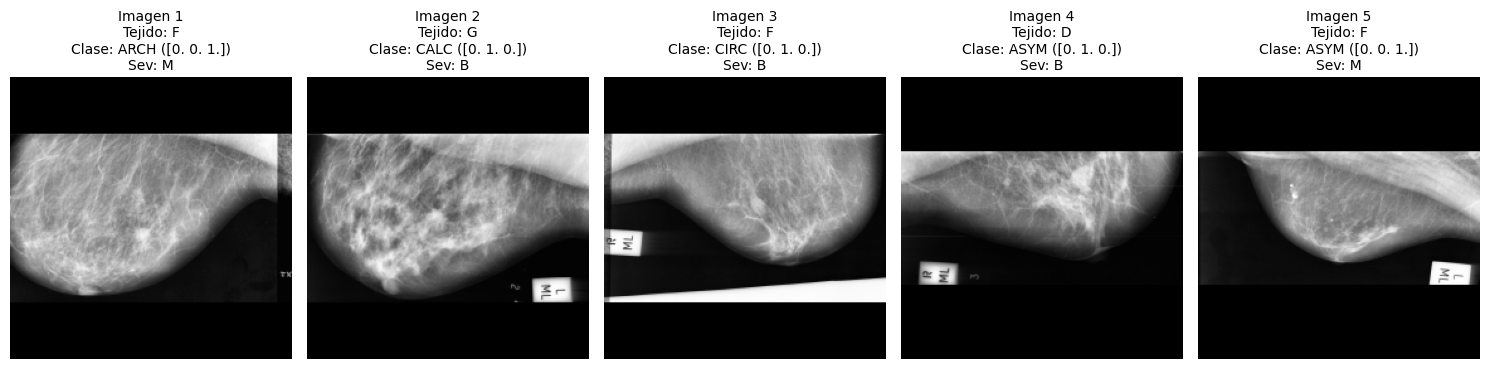

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(15, 6))

for i in range(5):
    axes[i].imshow(X_train[i], cmap='gray')
    
    tejido = df_train.iloc[i]['tejido']
    clase = df_train.iloc[i]['clase']
    severidad = df_train.iloc[i]['severidad']
    label_binario = y_train[i]
    
    titulo = f"Imagen {i+1}\nTejido: {tejido}\nClase: {clase} ({label_binario})\nSev: {severidad}"
    
    axes[i].set_title(titulo, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation

Dataset expansion steps implemented:

* **Dynamic Spatial Transformations:** Applies horizontal flips ($50\%$ chance), vertical flips ($20\%$ chance), and $90^\circ$ rotations ($50\%$ chance) to help the model learn rotation-invariant medical features.
* **Affine Elasticity (`ShiftScaleRotate`):** Introduces minor random shifts, scaling, and small rotations up to $15^\circ$, forcing the network to become robust against slight differences in tissue positioning and scaling.
* **Lighting Normalization (`RandomBrightnessContrast`):** Slightly jitters brightness and contrast levels ($\pm 10\%$) to simulate variances in scanner exposure and imaging conditions without destroying clinical features.
* **Dataset Multiplier Setup:** Implements a replica loops system that preserves the original untouched image while generating `num_replicas` new, uniquely augmented variations of it.
* **Synchronized Target Mapping:** Automatically duplicates the corresponding class label (`y_set`) for every newly generated image variation, keeping the ground truth perfectly aligned.

In [21]:
from collections import Counter

transform_train = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5)
])

def aplicar_data_augmentation_balanceado(X_set, y_set):
    y_integers = np.argmax(y_set, axis=1) if len(y_set.shape) > 1 and y_set.shape[1] > 1 else y_set
    conteo_clases = Counter(y_integers)
    max_muestras = max(conteo_clases.values())

    X_balanceado = []
    y_balanceado = []

    datos_por_clase = {clase: [] for clase in conteo_clases.keys()}
    for img, label, cls_int in zip(X_set, y_set, y_integers):
        datos_por_clase[cls_int].append((img, label))

    for clase, elementos in datos_por_clase.items():
        cant_original = len(elementos)
        for img, label in elementos:
            X_balanceado.append(img)
            y_balanceado.append(label)
        
        muestras_faltantes = max_muestras - cant_original
        if muestras_faltantes > 0:
            indices_a_aumentar = np.random.choice(cant_original, size=muestras_faltantes, replace=True)
            for idx in indices_a_aumentar:
                img_orig, label_orig = elementos[idx]
                augmented = transform_train(image=img_orig)
                X_balanceado.append(augmented['image'])
                y_balanceado.append(label_orig)

    X_balanceado = np.array(X_balanceado)
    y_balanceado = np.array(y_balanceado)

    indices_shuffled = np.arange(len(X_balanceado))
    np.random.shuffle(indices_shuffled)
    
    return X_balanceado[indices_shuffled], y_balanceado[indices_shuffled]

X_train_aug, y_train_aug = aplicar_data_augmentation_balanceado(X_train, y_train)

# Transfer learning

In [22]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Dropout, Add, Lambda, Multiply, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Concatenate
import gc
from tensorflow.keras.regularizers import l2

This sections is the one that took the most time, because we realized the transfer learning with 5 different models, we will explore its differences.

First we define some general things for all models, we use model checkpoint to get the best one and also early stopping to save in computation. 

In [23]:
# --- Preprocesamiento y Asignaciones (Verificado) ---
X_train_final = np.expand_dims(X_train_aug.astype(np.float32) , axis=-1)
X_val_final = np.expand_dims(X_val.astype(np.float32) , axis=-1)
X_test_final = np.expand_dims(X_test.astype(np.float32) , axis=-1)

y_train_final_3c = y_train_aug

BATCH_SIZE = 32  
EPOCHS = 100     

def obtener_callbacks(nombre_modelo):
    """Genera los callbacks de control guardando únicamente los pesos del modelo"""
    return [
        ModelCheckpoint(
            filepath=f'mejor_{nombre_modelo}.weights.h5', 
            monitor='val_loss', 
            save_best_only=True, 
            save_weights_only=True,                      
            verbose=1
        ),
        #EarlyStopping(
        #    monitor='val_loss',
        #    patience=20,           
        #    restore_best_weights=True 
        #)
    ]

We prepare the data for the training, also here we compensate for the imbalanced in the different classes so we add a weight proportional to each imbalanced. (depracated)

## MobileNetV3

### General MobileNetV3 Layers

* **Standard Convolutional Stem (`Conv2D`)**: The very first layer. It performs initial high-stride spatial filtering directly on the input image.
* **Inverted Residual Blocks (`MBConv`)**: The building blocks of the network. They expand the channels temporarily, apply depthwise filtering, and then project them back down to save memory.
* **Depthwise Separable Convolutions (`DepthwiseConv2D`)**: Instead of standard 3D filters, it splits computation into a 2D spatial filter per channel, followed by a $1 \times 1$ pointwise filter.
* **Squeeze-and-Excitation Blocks (`SE`)**: An attention mechanism that scales each channel's importance by dynamically calculating global global context.
* **Pointwise Convolutions (`$1 \times 1$ Conv2D`)**: Linearly combines the spatial features across channels before entering the final pooling stage.
* **Global Average Pooling (`GAP`)**: Condenses the 2D feature maps into a 1D vector to feed the classification head.

---

### Custom Transfer Learning Modifications

1. **Custom Input Channel Adapter (`Conv2D`)**: Added a trainable layer with 3 filters at the start. This projects the 1-channel grayscale images into a 3-channel space, enabling compatibility with pre-trained RGB weights.
2. **Frozen Feature Extractor (`trainable=False`)**: Completely locks the weights of all standard MobileNetV3 layers so the pre-trained ImageNet features are not destroyed during training.
3. **Global Average Pooling Layer (`GAP`)**: Replaces the default MobileNet classification layers to collapse spatial dimensions.
4. **Regularization Layer (`Dropout 0.3`)**: Added immediately before classification to reduce overfitting on the specialized medical dataset.
5. **Custom Dense Head (`Softmax, 3 Units`)**: A newly initialized dense layer mapping the features directly to the three target classes (Normal, Benign, and Malignant).

In [24]:
# =====================================================================
# --- MODELO 1: FCN ESTÁNDAR (MobileNetV3) ---
# =====================================================================

from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

inputs_fcn = Input(shape=(None, None, 1), name='input_fcn_estandar')

x_fcn = inputs_fcn * 255.0
x_fcn = Concatenate()([x_fcn, x_fcn, x_fcn])
x_fcn = tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v3.preprocess_input(x))(x_fcn)

base_model_fcn = tf.keras.applications.MobileNetV3Large(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3)
)
base_model_fcn.trainable = False

x_fcn = base_model_fcn(x_fcn)

x_fcn = GlobalAveragePooling2D()(x_fcn)
x_fcn = BatchNormalization()(x_fcn)
x_fcn = Dropout(0.4)(x_fcn)

x_fcn = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_fcn)
x_fcn = BatchNormalization()(x_fcn)
x_fcn = Dropout(0.3)(x_fcn)

outputs_fcn = Dense(3, activation='softmax', name='fcn_output')(x_fcn)

model_fcn = Model(inputs=inputs_fcn, outputs=outputs_fcn, name='FCN_MobileNetV3')

model_fcn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_fcn.summary()

Model: "FCN_MobileNetV3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_fcn_estandar (InputLayer  [(None, None, None,  0          []                               
 )                               1)]                                                              
                                                                                                  
 tf.math.multiply_1 (TFOpLambda  (None, None, None,   0          ['input_fcn_estandar[0][0]']     
 )                              1)                                                                
                                                                                                  
 concatenate (Concatenate)      (None, None, None,   0           ['tf.math.multiply_1[0][0]',     
                                3)                                'tf.math.multiply_

In [25]:
history_fcn = model_fcn.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),  
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_fcn'),
    verbose=1
)


print("\n--- Test ---")
test_loss_fcn, test_acc_fcn, test_auc_fcn = model_fcn.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"FCN Estándar -> Pérdida: {test_loss_fcn:.4f} | Precisión: {test_acc_fcn:.4f} | AUC: {test_auc_fcn:.4f}")

tf.keras.backend.clear_session()
gc.collect()

Epoch 1/100


2026-07-15 21:47:05.596490: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8902
2026-07-15 21:47:05.963415: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f600613f490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-15 21:47:05.963437: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-07-15 21:47:05.967439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-15 21:47:06.055727: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 [==============================] - ETA: 0s - loss: 1.6721 - accuracy: 0.4038 - auc: 0.5701
Epoch 1: val_loss improved from inf to 0.78975, saving model to mejor_model_fcn.weights.h5
14/14 [==============================] - 5s 120ms/step - loss: 1.6721 - accuracy: 0.4038 - auc: 0.5701 - val_loss: 0.7898 - val_accuracy: 0.7500 - val_auc: 0.4126
Epoch 2/100
13/14 [==========================>...] - ETA: 0s - loss: 1.0124 - accuracy: 0.6130 - auc: 0.7734
Epoch 2: val_loss did not improve from 0.78975
14/14 [==============================] - 0s 19ms/step - loss: 1.0337 - accuracy: 0.6080 - auc: 0.7682 - val_loss: 0.7926 - val_accuracy: 0.7292 - val_auc: 0.4623
Epoch 3/100
12/14 [========================>.....] - ETA: 0s - loss: 0.8279 - accuracy: 0.6719 - auc: 0.8399
Epoch 3: val_loss did not improve from 0.78975
14/14 [==============================] - 0s 19ms/step - loss: 0.8142 - accuracy: 0.6808 - auc: 0.8445 - val_loss: 0.8845 - val_accuracy: 0.6042 - val_auc: 0.5153
Epoch 4/100
1

2318

## MoE con MobileNetV3

### Custom Mixture of Experts (MoE) Architecture

Instead of relying on a single dense layer to make the final prediction, this model splits the decision-making process across a routing network and multiple specialized networks, it is probably not that necessary for a model this small with this small data set  but still just as a experiment.

These are the core, underlined layers and steps of the MoE implementation:

* **Common Feature Extraction Base**: Relies on the same custom 3-channel input adapter and frozen `MobileNetV3` backbone, compressed via `GlobalAveragePooling2D` and `Dropout` to output a unified **Shared Feature Vector**.
* **Gating Network (`gating_network`)**: A 3-unit `Dense` layer with `softmax` activation. It acts as the **router/manager**, looking at the shared feature vector and dynamically deciding which expert to trust by assigning a probability weight to each one (e.g., $g_1$, $g_2$, $g_3$).
* **Specialized Experts (`Dense` Blocks)**: Three independent parallel subnetworks (each with a 128-unit `ReLU` layer followed by a 3-unit `softmax` output) that focus on different clinical features:
* **Expert 1**: Specializes in fine textures (like microcalcifications or asymmetries).
* **Expert 2**: Specializes in dense structural regions (like masses and architectural distortions).
* **Expert 3**: A generic expert focused on normal tissue patterns and baseline variations.


* **Dynamic Weighting (`Lambda` & `Multiply`)**: Slice layers (`Lambda`) isolate each gating weight and multiply them (`Multiply`) against the output of their corresponding expert. This dynamically scales down the "opinions" of unselected experts.
* **Weighted Summation (`Add`)**: The final output layer sums the three weighted predictions into a single, cohesive 3-class classification vector (Normal, Benign, Malignant).

In [26]:
# =====================================================================
# --- MODELO 2: FCN CON MIXTURE OF EXPERTS (MoE con MobileNetV3) ---
# =====================================================================

inputs_moe = Input(shape=(None, None, 1), name='input_fcn_moe')

x_moe = inputs_moe * 255.0
x_moe = Concatenate()([x_moe, x_moe, x_moe])
x_moe = tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v3.preprocess_input(x))(x_moe)

base_model_moe = tf.keras.applications.MobileNetV3Large(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3)
)
base_model_moe.trainable = False
features_moe = base_model_moe(x_moe)

shared_vector = GlobalAveragePooling2D()(features_moe)
shared_vector = BatchNormalization()(shared_vector)
shared_vector = Dropout(0.4)(shared_vector)

gate_weights = Dense(3, activation='softmax', kernel_regularizer=l2(1e-3), name='gating_network')(shared_vector)

expert_1 = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(shared_vector)
expert_1 = BatchNormalization()(expert_1)
expert_1_out = Dense(3, activation='softmax', name='expert_calcificaciones')(expert_1)

expert_2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(shared_vector)
expert_2 = BatchNormalization()(expert_2)
expert_2_out = Dense(3, activation='softmax', name='expert_masas')(expert_2)

expert_3 = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(shared_vector)
expert_3 = BatchNormalization()(expert_3)
expert_3_out = Dense(3, activation='softmax', name='expert_general')(expert_3)

g1 = Lambda(lambda g: tf.expand_dims(g[:, 0], axis=-1), name='weight_expert_1')(gate_weights)
g2 = Lambda(lambda g: tf.expand_dims(g[:, 1], axis=-1), name='weight_expert_2')(gate_weights)
g3 = Lambda(lambda g: tf.expand_dims(g[:, 2], axis=-1), name='weight_expert_3')(gate_weights)

w_expert1 = Multiply()([expert_1_out, g1])
w_expert2 = Multiply()([expert_2_out, g2])
w_expert3 = Multiply()([expert_3_out, g3])

outputs_moe = Add(name='moe_output')([w_expert1, w_expert2, w_expert3])

model_fcn_moe = Model(inputs=inputs_moe, outputs=outputs_moe, name='FCN_MoE_MobileNetV3')

model_fcn_moe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_fcn_moe.summary()

Model: "FCN_MoE_MobileNetV3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_fcn_moe (InputLayer)     [(None, None, None,  0           []                               
                                 1)]                                                              
                                                                                                  
 tf.math.multiply (TFOpLambda)  (None, None, None,   0           ['input_fcn_moe[0][0]']          
                                1)                                                                
                                                                                                  
 concatenate (Concatenate)      (None, None, None,   0           ['tf.math.multiply[0][0]',       
                                3)                                'tf.math.multi

In [27]:
history_moe = model_fcn_moe.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_fcn_moe'),
    verbose=1
)

print("\n--- Test ---")
test_loss_moe, test_acc_moe, test_auc_moe = model_fcn_moe.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"FCN con MoE   -> Pérdida: {test_loss_moe:.4f} | Precisión: {test_acc_moe:.4f} | AUC: {test_auc_moe:.4f}")

tf.keras.backend.clear_session()
gc.collect()

Epoch 1/100
11/14 [======================>.......] - ETA: 0s - loss: 1.3840 - accuracy: 0.3835 - auc: 0.5546
Epoch 1: val_loss improved from inf to 0.87318, saving model to mejor_model_fcn_moe.weights.h5
14/14 [==============================] - 6s 175ms/step - loss: 1.3269 - accuracy: 0.4085 - auc: 0.5866 - val_loss: 0.8732 - val_accuracy: 0.7500 - val_auc: 0.4803
Epoch 2/100
13/14 [==========================>...] - ETA: 0s - loss: 0.7953 - accuracy: 0.6779 - auc: 0.8525
Epoch 2: val_loss improved from 0.87318 to 0.85671, saving model to mejor_model_fcn_moe.weights.h5
14/14 [==============================] - 1s 53ms/step - loss: 0.7870 - accuracy: 0.6808 - auc: 0.8563 - val_loss: 0.8567 - val_accuracy: 0.7292 - val_auc: 0.5160
Epoch 3/100
13/14 [==========================>...] - ETA: 0s - loss: 0.5858 - accuracy: 0.7837 - auc: 0.9333
Epoch 3: val_loss improved from 0.85671 to 0.84706, saving model to mejor_model_fcn_moe.weights.h5
14/14 [==============================] - 1s 54ms/step -

2388

## EfficientNetB0
### General EfficientNetB0 Layers

* **Standard Conv Stem (`Conv2d` with Swish)**: The initial entry layer of the model, which extracts basic textures using the computationally efficient *Swish* activation.
* **Mobile Inverted Bottleneck Convolution Blocks (`MBConv`)**: Highly optimized blocks that use depthwise separable convolutions, shortcut connections, and expansion phases. Unlike MobileNetV3, these are scaled precisely using **Compound Scaling** (balancing depth, width, and resolution simultaneously).
* **Squeeze-and-Excitation Blocks (`SE`)**: Integrated directly into the `MBConv` blocks to dynamically weight and prioritize active channel-wise features.
* **Batch Normalization Layers (`BatchNorm`)**: Placed after convolutional steps to stabilize and accelerate training by normalizing activations.
* **Final Conv Head ($1 \times 1$)**: Scales up the channels before the final pooling stage to prepare high-dimensional features.

---

### Custom Transfer Learning Modifications

1. **Custom Input Channel Adapter (`Conv2D`)**: A trainable layer with 3 filters that transforms the 1-channel grayscale inputs into a 3-channel space, enabling compatibility with pre-trained RGB ImageNet weights.
2. **Global Average Pooling Layer (`GAP`)**: Condenses the spatial 2D feature maps outputted by the backbone into a flat 1D feature vector.
3. **Regularization Layer (`Dropout 0.3`)**: Added immediately before the output to drop 30% of activations randomly, preventing overfitting on the medical images.
4. **Custom Dense Head (`Softmax, 3 Units`)**: A newly initialized dense layer mapping the final features to the three target classes (Normal, Benign, and Malignant).

In [28]:
# =====================================================================
# --- MODELO 3: CNN ALTERNATIVA (EfficientNetB0) ---
# =====================================================================
import keras 

inputs_cnn = Input(shape=(None, None, 1), name='input_cnn_alternativo')

x_cnn = inputs_cnn * 255.0
x_cnn = Concatenate()([x_cnn, x_cnn, x_cnn])
x_cnn = tf.keras.layers.Lambda(lambda x: tf.keras.applications.efficientnet.preprocess_input(x))(x_cnn)

base_model_cnn = tf.keras.applications.EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=(None, None, 3)
)
base_model_cnn.trainable = False

x_cnn = base_model_cnn(x_cnn)

x_cnn = GlobalAveragePooling2D()(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Dropout(0.4)(x_cnn)

x_cnn = Dense(256, activation='swish', kernel_regularizer=l2(1e-4))(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = Dropout(0.3)(x_cnn)

outputs_cnn = Dense(3, activation='softmax', name='cnn_output')(x_cnn)
model_cnn = Model(inputs=inputs_cnn, outputs=outputs_cnn, name='CNN_EfficientNetB0')

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)] 
)
model_cnn.summary()

Model: "CNN_EfficientNetB0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_cnn_alternativo (InputLa  [(None, None, None,  0          []                               
 yer)                            1)]                                                              
                                                                                                  
 tf.math.multiply (TFOpLambda)  (None, None, None,   0           ['input_cnn_alternativo[0][0]']  
                                1)                                                                
                                                                                                  
 concatenate (Concatenate)      (None, None, None,   0           ['tf.math.multiply[0][0]',       
                                3)                                'tf.math.multip

In [29]:
tf.keras.backend.clear_session()
gc.collect()


history_cnn = model_cnn.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),  
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_cnn'),
    verbose=1
)


print("\n--- Test ---")
test_loss_cnn, test_acc_cnn, test_auc_cnn = model_cnn.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"CNN Alternativo -> Pérdida: {test_loss_cnn:.4f} | Precisión: {test_acc_cnn:.4f} | AUC: {test_auc_cnn:.4f}")


Epoch 1/100
14/14 [==============================] - ETA: 0s - loss: 1.5877 - accuracy: 0.4437 - auc: 0.6343
Epoch 1: val_loss improved from inf to 0.80714, saving model to mejor_model_cnn.weights.h5
14/14 [==============================] - 6s 144ms/step - loss: 1.5877 - accuracy: 0.4437 - auc: 0.6343 - val_loss: 0.8071 - val_accuracy: 0.7708 - val_auc: 0.4372
Epoch 2/100
13/14 [==========================>...] - ETA: 0s - loss: 0.9128 - accuracy: 0.6707 - auc: 0.8384
Epoch 2: val_loss improved from 0.80714 to 0.77835, saving model to mejor_model_cnn.weights.h5
14/14 [==============================] - 1s 56ms/step - loss: 0.9273 - accuracy: 0.6667 - auc: 0.8355 - val_loss: 0.7783 - val_accuracy: 0.7708 - val_auc: 0.5441
Epoch 3/100
12/14 [========================>.....] - ETA: 0s - loss: 0.7639 - accuracy: 0.6927 - auc: 0.8752
Epoch 3: val_loss did not improve from 0.77835
14/14 [==============================] - 0s 28ms/step - loss: 0.7438 - accuracy: 0.6995 - auc: 0.8808 - val_loss: 0

## ResNet50

### General ResNet50 Layers

* **Standard Conv Stem (`Conv2d` with ReLU)**: The initial entry layer of the model, which performs downsampling and extracts basic edge features using a $7 \times 7$ kernel followed by Max Pooling.
* **Residual Bottleneck Blocks**: Deep architectural blocks designed to combat the vanishing gradient problem. They utilize identity shortcut connections that bypass one or more layers, allowing gradients to flow directly through the network.
* **Bottleneck Design ($1 \times 1 \rightarrow 3 \times 3 \rightarrow 1 \times 1$)**: Each residual block compresses channels with a $1 \times 1$ convolution, processes spatial features with a $3 \times 3$ convolution, and restores the channel dimension with another $1 \times 1$ step.
* **Batch Normalization Layers (`BatchNorm`)**: Integrated after every convolutional operation to reduce internal covariate shift and ensure stable, fast convergence.
* **Global Spatial Representations**: High-level abstract features are constructed at the deepest layers of the backbone before reaching the final classification stages.

---

### Custom Transfer Learning Modifications

1. **Custom Input Channel Adapter (`Conv2D`)**: A trainable convolutional layer with 3 filters and a $3 \times 3$ kernel size that projects the 1-channel grayscale input into a 3-channel feature space, ensuring compatibility with the pre-trained ImageNet RGB weights.
2. **Global Average Pooling Layer (`GAP`)**: Replaces the standard flattening step by average-pooling the spatial 2D dimensions of the final ResNet50 feature maps, yielding a robust 1D feature vector.
3. **Regularization Layer (`Dropout 0.3`)**: Added immediately after pooling to randomly deactivate 30% of the neurons during training, reducing overfitting on the specialized medical dataset.
4. **Custom Dense Head (`Softmax, 3 Units`)**: A newly appended fully-connected layer that maps the regularized 1D features to the probability distribution of the three target clinical classes (Normal, Benign, and Malignant).

In [30]:
# =====================================================================
# --- MODELO 3: RESNET50 (Transfer Learning con Ajuste de Resolución) ---
# =====================================================================

inputs_resnet = Input(shape=(224, 224, 1), name='input_resnet50')

x_resnet = inputs_resnet * 255.0
x_resnet = Concatenate()([x_resnet, x_resnet, x_resnet])
x_resnet = tf.keras.layers.Lambda(lambda x: tf.keras.applications.resnet50.preprocess_input(x))(x_resnet)

base_model_resnet = keras.applications.ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)
base_model_resnet.trainable = False

x_resnet = base_model_resnet(x_resnet)

x_resnet = GlobalAveragePooling2D()(x_resnet)
x_resnet = Dropout(0.5)(x_resnet)

outputs_resnet = Dense(3, activation='softmax', name='resnet_output')(x_resnet)
model_resnet = Model(inputs=inputs_resnet, outputs=outputs_resnet, name='CNN_ResNet50')

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-3, clipvalue=1.0),
    loss='categorical_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)] 
)

model_resnet.summary()

tf.keras.backend.clear_session()
gc.collect()

history_resnet = model_resnet.fit(
    X_train_final, y_train_final_3c,       
    validation_data=(X_val_final, y_val),  
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_resnet'),
    verbose=1
)

print("\n--- Test ---")
test_loss_resnet, test_acc_resnet, test_auc_resnet = model_resnet.evaluate(
    X_test_final, y_test, 
    batch_size=BATCH_SIZE, 
    verbose=0
)
print(f"ResNet50 -> Pérdida: {test_loss_resnet:.4f} | Precisión: {test_acc_resnet:.4f} | AUC: {test_auc_resnet:.4f}")

tf.keras.backend.clear_session()
gc.collect()

Model: "CNN_ResNet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_resnet50 (InputLayer)    [(None, 224, 224, 1  0           []                               
                                )]                                                                
                                                                                                  
 tf.math.multiply (TFOpLambda)  (None, 224, 224, 1)  0           ['input_resnet50[0][0]']         
                                                                                                  
 concatenate (Concatenate)      (None, 224, 224, 3)  0           ['tf.math.multiply[0][0]',       
                                                                  'tf.math.multiply[0][0]',       
                                                                  'tf.math.multiply[0][

2392

## ConvNeXt Tiny
### General ConvNeXt Tiny Layers

* **Patchify Stem (`Conv2D` with stride 4)**: Unlike older architectures, ConvNeXt processes inputs using non-overlapping patches (similar to Vision Transformers), implemented via a $4 \times 4$ convolution with a stride of 4.
* **Depthwise Convolutions with Large Kernels ($7 \times 7$)**: Replaces the traditional $3 \times 3$ convolutional filters with larger $7 \times 7$ kernels to increase the receptive field, mimicking the global self-attention mechanism of Transformers.
* **Inverted Bottleneck Blocks**: Features are expanded into a higher dimension and then projected back down using pointwise $1 \times 1$ convolutions to keep parameter count efficient.
* **Layer Normalization (`LayerNorm`)**: Used instead of traditional Batch Normalization (another design choice borrowed from Transformers) to stabilize internal representations.
* **GELU Activation Functions**: Swaps standard ReLU activations for Gaussian Error Linear Units (GELU) to improve gradient flow and model accuracy.

---

### Custom Transfer Learning Modifications

These are the exact code modifications applied to adapt this ConvNeXt Tiny backbone to the 1-channel grayscale medical dataset:

1. **Custom Input Channel Adapter (`Conv2D`)**: A trainable layer with 3 filters that transforms the 1-channel grayscale inputs ($224 \times 224 \times 1$) into a 3-channel space, enabling compatibility with pre-trained RGB weights.
2. **Frozen Feature Extractor (`trainable=False`)**: Locks the entire `ConvNeXtTiny` backbone to prevent catastrophic forgetting and avoid memorizing training data too quickly.
3. **Global Average Pooling Layer (`GAP`)**: Flattens the spatial output maps from ConvNeXt into a 1D feature vector.
4. **Heavy Regularization (`BatchNormalization` + `Dropout 0.5`)**: Added specifically after the backbone to force robustness and combat validation accuracy drops by aggressively cutting 50% of the activations during training.
5. **Penalized Dense Head (`L2 Regularization` + `Softmax`)**: A newly initialized 3-unit dense output layer featuring $L2$ kernel regularization (`l2(0.01)`) to restrict weight magnitude, directly mapping the outputs to the three target classes (Normal, Benign, Malignant).

In [ ]:
try:
    # este cambio fue necesario pues habia un error con el float16 mixed de unas capas que no podian ser convertidas para este modelo
    import keras.applications.convnext as convnext_module
    original_call = convnext_module.LayerScale.call
    def patched_call(self, x):
        return x * tf.cast(self.gamma, dtype=x.dtype)
    convnext_module.LayerScale.call = patched_call
except Exception as e:
    print(f"{e}")

tf.keras.backend.clear_session()
gc.collect()

inputs_convnext = Input(shape=(224, 224, 1), name='input_convnext')

x_convnext = Conv2D(3, (3, 3), padding='same', activation='relu')(inputs_convnext)

base_model_convnext = keras.applications.ConvNeXtTiny(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_convnext.trainable = False

x_convnext = base_model_convnext(x_convnext)
x_convnext = GlobalAveragePooling2D()(x_convnext)

x_convnext = BatchNormalization()(x_convnext)
x_convnext = Dropout(0.5)(x_convnext)  

outputs_convnext = Dense(
    3, 
    activation='softmax', 
    kernel_regularizer=l2(0.01), 
    name='convnext_output'
)(x_convnext)

model_convnext = Model(inputs=inputs_convnext, outputs=outputs_convnext, name='ConvNeXt_Tiny')

model_convnext.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

model_convnext.summary()

tf.keras.backend.clear_session()
gc.collect()

history_convnext = model_convnext.fit(
    X_train_final, y_train_final_3c,
    validation_data=(X_val_final, y_val),
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=obtener_callbacks('model_convnext'),
    verbose=1
)

print("\n--- Test ---")
test_loss_convnext, test_acc_convnext, test_auc_convnext = model_convnext.evaluate(
    X_test_final, y_test,
    batch_size=BATCH_SIZE,
    verbose=0
)
print(f"ConvNeXt -> Pérdida: {test_loss_convnext:.4f} | Precisión: {test_acc_convnext:.4f} | AUC: {test_auc_convnext:.4f}")


tf.keras.backend.clear_session()
gc.collect()

Model: "ConvNeXt_Tiny"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_convnext (InputLayer)  [(None, 224, 224, 1)]    0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 3)       30        
                                                                 
 convnext_tiny (Functional)  (None, 7, 7, 768)         27820128  
                                                                 
 global_average_pooling2d (G  (None, 768)              0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 768)              3072      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 768)             

2388

So finally we got the result, this graphs will be discus at the end of iterations

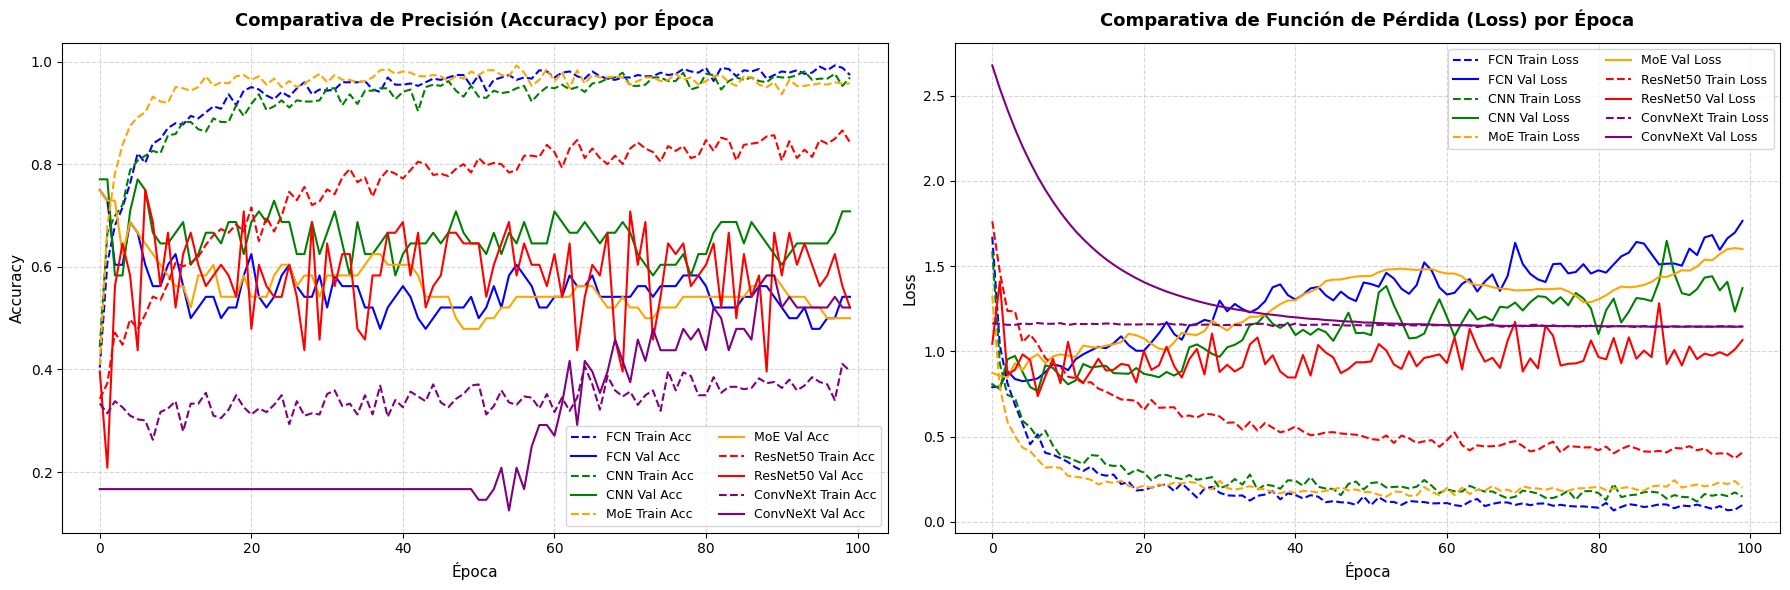

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(history_fcn.history['accuracy'], label='FCN Train Acc', color='blue', linestyle='--')
ax1.plot(history_fcn.history['val_accuracy'], label='FCN Val Acc', color='blue', linestyle='-')
ax1.plot(history_cnn.history['accuracy'], label='CNN Train Acc', color='green', linestyle='--')
ax1.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc', color='green', linestyle='-')
ax1.plot(history_moe.history['accuracy'], label='MoE Train Acc', color='orange', linestyle='--')
ax1.plot(history_moe.history['val_accuracy'], label='MoE Val Acc', color='orange', linestyle='-')
ax1.plot(history_resnet.history['accuracy'], label='ResNet50 Train Acc', color='red', linestyle='--')
ax1.plot(history_resnet.history['val_accuracy'], label='ResNet50 Val Acc', color='red', linestyle='-')
ax1.plot(history_convnext.history['accuracy'], label='ConvNeXt Train Acc', color='purple', linestyle='--')
ax1.plot(history_convnext.history['val_accuracy'], label='ConvNeXt Val Acc', color='purple', linestyle='-')

ax1.set_title('Comparativa de Precisión (Accuracy) por Época', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(loc='lower right', fontsize=9, ncol=2)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(history_fcn.history['loss'], label='FCN Train Loss', color='blue', linestyle='--')
ax2.plot(history_fcn.history['val_loss'], label='FCN Val Loss', color='blue', linestyle='-')
ax2.plot(history_cnn.history['loss'], label='CNN Train Loss', color='green', linestyle='--')
ax2.plot(history_cnn.history['val_loss'], label='CNN Val Loss', color='green', linestyle='-')
ax2.plot(history_moe.history['loss'], label='MoE Train Loss', color='orange', linestyle='--')
ax2.plot(history_moe.history['val_loss'], label='MoE Val Loss', color='orange', linestyle='-')
ax2.plot(history_resnet.history['loss'], label='ResNet50 Train Loss', color='red', linestyle='--')
ax2.plot(history_resnet.history['val_loss'], label='ResNet50 Val Loss', color='red', linestyle='-')
ax2.plot(history_convnext.history['loss'], label='ConvNeXt Train Loss', color='purple', linestyle='--')
ax2.plot(history_convnext.history['val_loss'], label='ConvNeXt Val Loss', color='purple', linestyle='-')

ax2.set_title('Comparativa de Función de Pérdida (Loss) por Época', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(loc='upper right', fontsize=9, ncol=2)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

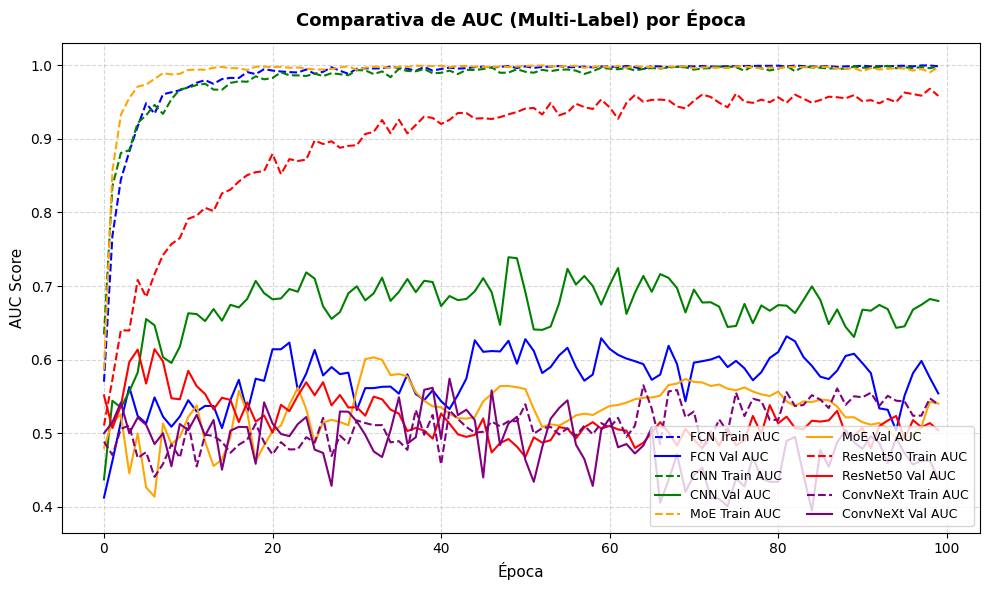

In [36]:
plt.figure(figsize=(10, 6))
colors = {
    'FCN': 'blue',
    'CNN': 'green',
    'MoE': 'orange',
    'ResNet50': 'red',
    'ConvNeXt': 'purple'
}

# Graficar Train y Val AUC para cada modelo
plt.plot(history_fcn.history['auc'], label='FCN Train AUC', color=colors['FCN'], linestyle='--')
plt.plot(history_fcn.history['val_auc'], label='FCN Val AUC', color=colors['FCN'], linestyle='-')

plt.plot(history_cnn.history['auc'], label='CNN Train AUC', color=colors['CNN'], linestyle='--')
plt.plot(history_cnn.history['val_auc'], label='CNN Val AUC', color=colors['CNN'], linestyle='-')

plt.plot(history_moe.history['auc'], label='MoE Train AUC', color=colors['MoE'], linestyle='--')
plt.plot(history_moe.history['val_auc'], label='MoE Val AUC', color=colors['MoE'], linestyle='-')

plt.plot(history_resnet.history['auc'], label='ResNet50 Train AUC', color=colors['ResNet50'], linestyle='--')
plt.plot(history_resnet.history['val_auc'], label='ResNet50 Val AUC', color=colors['ResNet50'], linestyle='-')

plt.plot(history_convnext.history['auc'], label='ConvNeXt Train AUC', color=colors['ConvNeXt'], linestyle='--')
plt.plot(history_convnext.history['val_auc'], label='ConvNeXt Val AUC', color=colors['ConvNeXt'], linestyle='-')

plt.title('Comparativa de AUC (Multi-Label) por Época', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Época', fontsize=11)
plt.ylabel('AUC Score', fontsize=11)
plt.legend(loc='lower right', fontsize=9, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

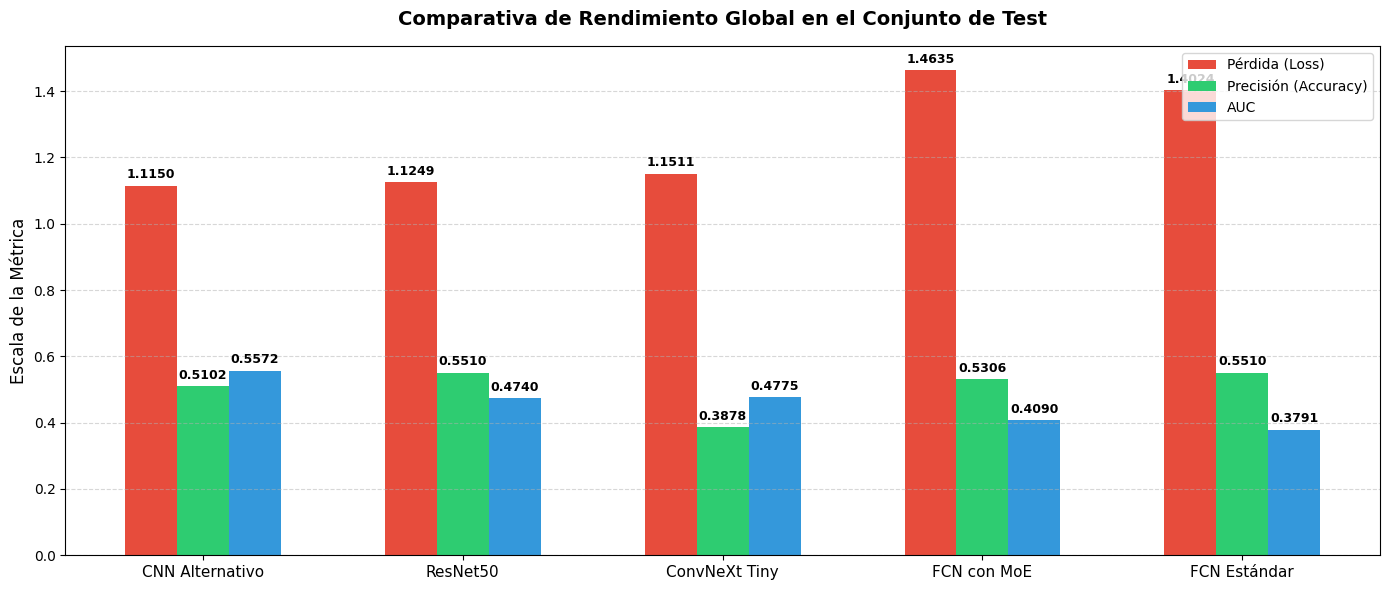

In [39]:
import numpy as np
import matplotlib.pyplot as plt

model_cnn.load_weights('mejor_model_cnn.weights.h5')
model_resnet.load_weights('mejor_model_resnet.weights.h5')
model_convnext.load_weights('mejor_model_convnext.weights.h5')
model_fcn_moe.load_weights('mejor_model_fcn_moe.weights.h5')
model_fcn.load_weights('mejor_model_fcn.weights.h5')

test_loss_cnn, test_acc_cnn, test_auc_cnn = model_cnn.evaluate(X_test_final, y_test, batch_size=BATCH_SIZE, verbose=0)
test_loss_resnet, test_acc_resnet, test_auc_resnet = model_resnet.evaluate(X_test_final, y_test, batch_size=BATCH_SIZE, verbose=0)
test_loss_convnext, test_acc_convnext, test_auc_convnext = model_convnext.evaluate(X_test_final, y_test, batch_size=BATCH_SIZE, verbose=0)
test_loss_moe, test_acc_moe, test_auc_moe = model_fcn_moe.evaluate(X_test_final, y_test, batch_size=BATCH_SIZE, verbose=0)
test_loss_fcn, test_acc_fcn, test_auc_fcn = model_fcn.evaluate(X_test_final, y_test, batch_size=BATCH_SIZE, verbose=0)

modelos = ['CNN Alternativo', 'ResNet50', 'ConvNeXt Tiny', 'FCN con MoE', 'FCN Estándar']
metricas = ['Pérdida', 'Precisión', 'AUC']

valores_loss = [test_loss_cnn, test_loss_resnet, test_loss_convnext, test_loss_moe, test_loss_fcn]
valores_acc = [test_acc_cnn, test_acc_resnet, test_acc_convnext, test_acc_moe, test_acc_fcn]
valores_auc = [test_auc_cnn, test_auc_resnet, test_auc_convnext, test_auc_moe, test_auc_fcn]

x = np.arange(len(modelos))  
width = 0.20                 

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(x - width, valores_loss, width, label='Pérdida (Loss)', color='#e74c3c')
rects2 = ax.bar(x, valores_acc, width, label='Precisión (Accuracy)', color='#2ecc71')
rects3 = ax.bar(x + width, valores_auc, width, label='AUC', color='#3498db')

ax.set_title('Comparativa de Rendimiento Global en el Conjunto de Test', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Escala de la Métrica', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

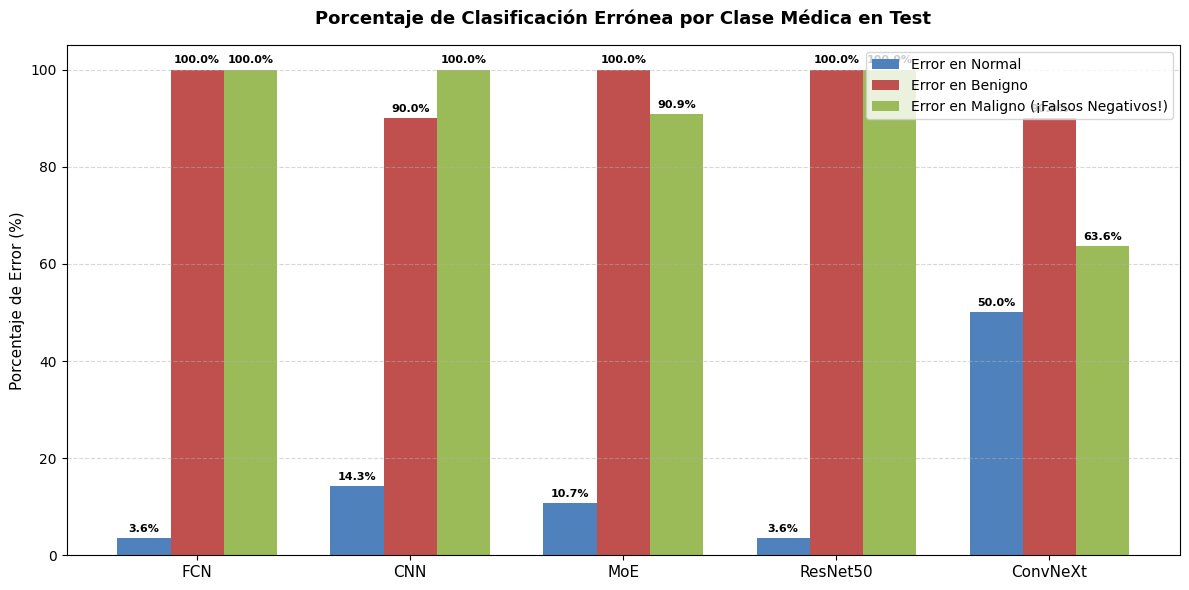

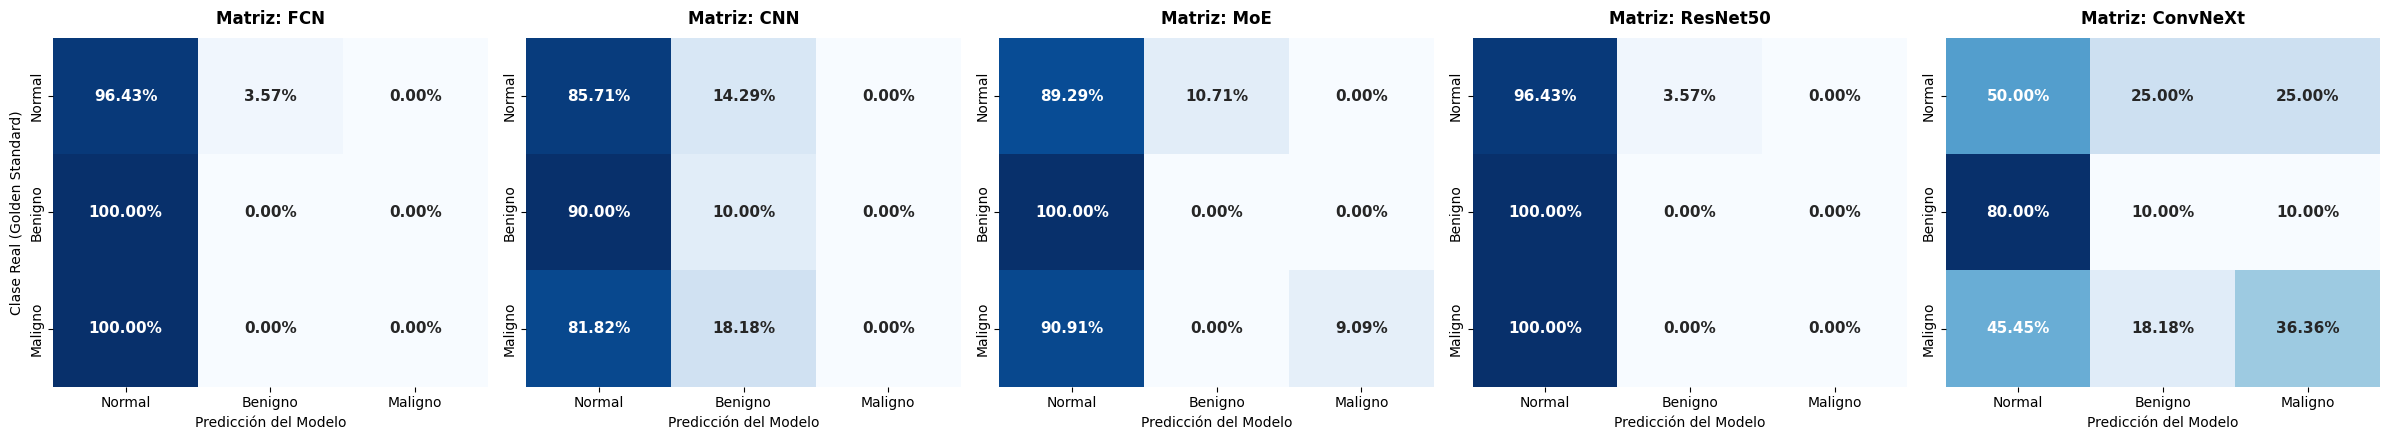

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_test_true = np.argmax(y_test, axis=1)

class_names = ['Normal', 'Benigno', 'Maligno']
model_names = ['FCN', 'CNN', 'MoE', 'ResNet50', 'ConvNeXt']

preds_dict = {
    'FCN': np.argmax(model_fcn.predict(X_test_final, batch_size=2, verbose=0), axis=1),
    'CNN': np.argmax(model_cnn.predict(X_test_final, batch_size=2, verbose=0), axis=1),
    'MoE': np.argmax(model_fcn_moe.predict(X_test_final, batch_size=2, verbose=0), axis=1),
    'ResNet50': np.argmax(model_resnet.predict(X_test_final, batch_size=2, verbose=0), axis=1),
    'ConvNeXt': np.argmax(model_convnext.predict(X_test_final, batch_size=2, verbose=0), axis=1)
}

error_por_clase = {class_name: [] for class_name in class_names}

for model in model_names:
    preds = preds_dict[model]
    cm = confusion_matrix(y_test_true, preds)

    for i, class_name in enumerate(class_names):
        total_real = np.sum(cm[i, :])
        aciertos = cm[i, i]
        tasa_error = ((total_real - aciertos) / total_real) * 100 if total_real > 0 else 0
        error_por_clase[class_name].append(tasa_error)

plt.figure(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.25

rects1 = plt.bar(x - width, error_por_clase['Normal'], width, label='Error en Normal', color='#4f81bd')
rects2 = plt.bar(x, error_por_clase['Benigno'], width, label='Error en Benigno', color='#c0504d')
rects3 = plt.bar(x + width, error_por_clase['Maligno'], width, label='Error en Maligno (¡Falsos Negativos!)', color='#9bbb59')

plt.ylabel('Porcentaje de Error (%)', fontsize=11)
plt.title('Porcentaje de Clasificación Errónea por Clase Médica en Test', fontsize=13, fontweight='bold', pad=15)
plt.xticks(x, model_names, fontsize=11)
plt.ylim(0, 105) # Escala de porcentaje
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

def label_bars(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

label_bars(rects1)
label_bars(rects2)
label_bars(rects3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))

for idx, model in enumerate(model_names):
    preds = preds_dict[model]
    cm = confusion_matrix(y_test_true, preds, normalize='true')
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt=".2%", 
        cmap="Blues", 
        xticklabels=class_names, 
        yticklabels=class_names, 
        cbar=False, 
        ax=axes[idx],
        annot_kws={"size": 11, "weight": "bold"}
    )
    axes[idx].set_title(f'Matriz: {model}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicción del Modelo')
    if idx == 0:
        axes[idx].set_ylabel('Clase Real (Golden Standard)')
    else:
        axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

# Iterations

## 1 iteration
This iteration was done with unbalanced classes, with freeze weights for each models, also all images were 1024x1024 which was really a test for the computation, it hadn't been put to scale how much of a difference it made, so also the batch was of 2, epochs 10.

The results speak for theme self, only 3 models were tested for limitations in computation, really any of theme was really learning anything.

<img src="image.png" alt="alt text" width="48%" /> <img src="image-1.png" alt="alt text" width="48%" />

## 2 iteration

The second iteration introduced balanced classes not trough the data set but through weights for each class. Training and validation were nearer to each other, it still was a really bad result

<img src="image-3.png" alt="alt text" width="48%" /> <img src="image-2.png" alt="alt text" width="48%" />

## 3 iteration

This time we try to unfreeze the weighs of the models, which probably isn't transfer learning but finetunning, but still we got similar result but it was clear something happened with CNN, which had probably a gradient explosion

<img src="image-5.png" alt="alt text" width="48%" /> <img src="image-6.png" alt="alt text" width="48%" />

## 4  iteration

The probable cause identified was that the normalizations layers of the model was creating that explotion which made sense because the batch was only of 2, so it made that more plausible, so only those layers were freeze, which resulted in eliminating the problem but still, no promising results. 

<img src="image-7.png" alt="alt text" width="48%" /> <img src="image-4.png" alt="alt text" width="48%" />

## 5 Iteration

This one was really a breakthrough, the image resolution past from 1024x1024 a 224x224, which really speedup thing up, it was know that this had impact, but it really wasn't put into proportion, so the batch past from 2 to 32, and still it was like half of the graphic memory utilization than with the higher resolution, this speed up allow to use 2 bigger models and still previous optimization were bigger used so the training was really fast. But still the result wasn't really promising. At least it seem the model could memoise with enough training.

<img src="image-10.png" alt="alt text" width="48%" /> <img src="image-11.png" alt="alt text" width="48%" />

## 6 Iteration

In this one we really get to what was happening a new test-graph was introduced, the confusion matrix, also we freezed the weights of the models again.

But it seem most models were just really learning one class and classifying all like that, eventhought, the classes were balanced through weight, so we did the balancing through the data in the data augmentation part but still the result were the same.

The most interesting was that the only one that wasn't memorizing one class was ConvNeXt, and in the Loss in train it wasn't improving at all, bit in validation it was improving it even seems like the train loss is something of an asymptotic limit for the validation, which is really a weird behavior for which i can't give any explanation.

![alt text](image-14.png)![alt text](image-15.png)![alt text](image-16.png)

We also did the same but with unfreeze weights which give really similar result with the difference that ConvNext also just memorize some class

![alt text](image-5.png)
![alt text](image-6.png)

## 7 Iteration

In our final attempt we try to fix the class normalization problem, applying the next strategies for each model

Here is the concrete summary of the normalization and architectural strategies implemented for each model to resolve the mode collapse issue:


### ResNet50

* **Input Range Restoration:** Scaled grayscale inputs by multiplying by 255.0 to restore the native dynamic range required by ImageNet-pretrained weights.
* **Deterministic Channel Expansion:** Replaced the trainable Conv2D projection with a Concatenate layer to clone the single channel three times, preserving spatial structure without risk of dead filters.
* **Native Preprocessing Integration:** Wrapped resnet50.preprocess_input in a Keras Lambda layer to ensure exact channel-mean subtraction on the $[0, 255]$ scale.
* **Gradient Control:** Applied gradient clipping (clipvalue=1.0) and raised the learning rate to 1e-3 to force the fresh classification head out of the majority-class local minimum.


### FCN (MobileNetV3)

* **Standardized Input Pipeline:** Implemented the identical $[0, 255]$ scaling, 3-channel concatenation, and MobileNetV3-specific preprocess_input flow.
* **Latent Space Projection:** Added an intermediate Dense(128) layer with ReLU activation to provide representation capacity between the highly compressed Global Average Pooling (GAP) features and the final predictions.
* **Covariance Shift Stabilization:** Inserted BatchNormalization before and after the projection layer to stabilize activation distributions during training.
* **Overfitting Control:** Combined L2 regularization (1e-4) and Dropout on the projection layer to penalize extreme weight values.


### FCN with Mixture of Experts (MoE with MobileNetV3)

* **Standardized Input Pipeline:** Implemented the identical $[0, 255]$ scaling, 3-channel concatenation, and MobileNetV3-specific preprocess_input flow.
* **Router (Gating) Regularization:** Applied L2 regularization (1e-3) directly to the routing network to prevent "routing collapse" (the tendency of the router to assign a weight of 1.0 to a single expert for all inputs).
* **Expert Normalization:** Isolated each of the three expert networks with its own BatchNormalization layer, ensuring that no single expert mathematically dominates the final weighted addition due to unscaled activations.
* **Expert Capacity Control:** Structured each expert with L2 regularized dense layers to maintain specialized, stable feature spaces.

### CNN (EfficientNetB0)

* **Standardized Input Pipeline:** Scaled inputs to $[0, 255]$, concatenated to 3 channels, and executed EfficientNet's native preprocess_input via Lambda.
* **Activation Coherence:** Configured a Dense(256) projection layer using the **Swish** activation function ($f(x) = x \cdot \sigma(x)$) to match the native architecture of EfficientNet, avoiding the sudden gradient truncation typical of ReLU.
* **Feature Rescaling:** Integrated dual BatchNormalization steps (before and after the Swish projection) to maintain clean feature boundaries.
* **Regularization Tuning:** Paired a higher-capacity hidden layer with L2 regularization (1e-4) and robust dropout to manage the larger parameter space safely.

### Final Result

even after applying this tactics it was clear we prevented the class memorization a little but pretty much it was the same for each model and any of theme was really learning, in an iteration i forgot to document, we changed the data augmentation, applying more variety in the transformation but the result were even worse which is already difficult. In ConvNext we also used L2 normalization but actually it made the model memorize more a class. Also we made 100 epochs just the see the behavior in the long time is clear the model can memorize but it can not really learn.

My conclusion is that some error has to had been done in the processing of data, i checked many times but i couldn't find an anomaly, so maybe the data is insufficient, and extracted some generalization of it is impossible for the models there is not enough information, but the ConvNext looks really promising for extracting really complex patterns, and still its behavior seems really weird, and a great subject to research in more deepness.